# 02 · Feature Engineering, Encoding & Feature Selection

**What's covered:**
1. Building engineered features with an explicit hypothesis behind each one
2. Encoding strategies: one-hot, ordinal, target/mean encoding (and the leakage trap inside it), frequency encoding
3. Multicollinearity (VIF) 
4. Feature selection: mutual information, RFECV, SelectFromModel — and whether selection actually helps

Self-contained: reads the raw CSV and rebuilds everything from scratch. The `load_and_clean` + `engineer_features` functions defined here are the canonical versions reused in Notebooks 3–6.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif, RFECV, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
RANDOM_STATE = 42

## 1. Load & clean

In [2]:
def load_and_clean(path='WA_FnUseC_TelcoCustomerChurn.csv'):
    df = pd.read_csv(path)
    df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)
    df['TotalCharges'] = df['TotalCharges'].fillna(0.0)
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    df = df.drop(columns=['customerID'])
    return df

df = load_and_clean()
print(df.shape)

(7043, 20)


## 2. Feature engineering

Every feature below encodes a specific hypothesis about *why* a customer churns, not just a transformation applied because it's available. That's the bar each one has to clear — "could I explain this to a retention team in one sentence?"

In [3]:
def engineer_features(df):
    df = df.copy()

    # Tenure has a strongly non-linear relationship with churn (early-tenure
    # customers churn far more than long-tenure ones); bucketing lets a linear
    # model pick that up and lets tree models split on it more efficiently.
    df['tenure_bucket'] = pd.cut(
        df['tenure'], bins=[-1, 12, 24, 36, 48, 60, 72],
        labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72']
    ).astype(str)

    # A customer's historical average monthly spend. tenure==0 customers have
    # no history yet, so we fall back to their current MonthlyCharges rather
    # than dividing by zero.
    df['charges_per_tenure_ratio'] = np.where(
        df['tenure'] > 0, df['TotalCharges'] / df['tenure'], df['MonthlyCharges']
    )

    # Current bill vs historical average — flags customers whose price
    # recently changed (e.g. a promo expiring), a classic churn trigger.
    # NOTE: Section 5 finds this is a perfect linear combination of the two
    # features above — kept here deliberately as a live example of a
    # multicollinearity issue, not fixed until we know exactly why it matters.
    df['monthly_charge_delta'] = df['MonthlyCharges'] - df['charges_per_tenure_ratio']

    # Contract type and payment method interact: month-to-month customers
    # paying by electronic check are a well-known high-risk combination in
    # this dataset (easiest to cancel + least "sticky" payment method).
    df['contract_payment'] = df['Contract'] + '_' + df['PaymentMethod']

    # How "invested" a customer is in the service ecosystem — more add-ons
    # subscribed to typically means more switching friction.
    addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                  'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['num_addon_services'] = (df[addon_cols] == 'Yes').sum(axis=1)

    # Brand-new customers (<=3 months) are in a distinct risk regime —
    # "buyer's remorse" churn looks different from long-tenure churn.
    df['is_new_customer'] = (df['tenure'] <= 3).astype(int)

    return df

df = engineer_features(df)
print(df.shape)
df[['tenure', 'tenure_bucket', 'charges_per_tenure_ratio', 'monthly_charge_delta',
    'contract_payment', 'num_addon_services', 'is_new_customer']].head()

(7043, 26)


,tenure,tenure_bucket,charges_per_tenure_ratio,monthly_charge_delta,contract_payment,num_addon_services,is_new_customer
0,1,0-12,29.850000,0.000000,Month-to-month_Electronic check,1,1
1,34,25-36,55.573529,1.376471,One year_Mailed check,2,0
2,2,0-12,54.075000,-0.225000,Month-to-month_Mailed check,2,1
3,45,37-48,40.905556,1.394444,One year_Bank transfer (automatic),3,0
4,2,0-12,75.825000,-5.125000,Month-to-month_Electronic check,0,1


In [4]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, churn rate {y_train.mean():.3f}")
print(f"Test:  {X_test.shape}, churn rate {y_test.mean():.3f}")

Train: (5634, 25), churn rate 0.265
Test:  (1409, 25), churn rate 0.265


## 3. Encoding strategies

Four ways to turn a categorical column into something a model can consume, each with a different trade-off.

### 3.1 One-hot encoding — the default, and what's used throughout this project

Creates one binary column per category. No ordering is assumed, which is correct for a nominal variable like `PaymentMethod`, but it throws away ordering information when there *is* a natural order (like `Contract`), and it inflates dimensionality fast on high-cardinality columns (not a problem here — the widest column, `PaymentMethod`, only has 4 categories).

In [5]:
ohe = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
ohe_out = ohe.fit_transform(X_train[['Contract']])
print(ohe.get_feature_names_out(['Contract']))
print(ohe_out[:5])

['Contract_One year' 'Contract_Two year']
[[0. 0.]
 [0. 0.]
 [0. 1.]
 [0. 1.]
 [0. 0.]]


### 3.2 Ordinal encoding — when categories have a real order

`Contract` isn't just three unrelated labels — `Month-to-month < One year < Two year` is a real progression, and a tree model can exploit that ordering with a single split ("contract length <= 1 year") instead of needing two separate one-hot splits to express the same idea. This only makes sense for genuinely ordinal columns; forcing an arbitrary order onto `PaymentMethod` would inject a fake relationship that isn't there.

In [6]:
contract_order = [['Month-to-month', 'One year', 'Two year']]
ord_enc = OrdinalEncoder(categories=contract_order)
X_train[['Contract_ordinal']] = ord_enc.fit_transform(X_train[['Contract']])
print(X_train[['Contract', 'Contract_ordinal']].drop_duplicates().sort_values('Contract_ordinal'))
X_train = X_train.drop(columns=['Contract_ordinal'])

            Contract  Contract_ordinal
3738  Month-to-month               0.0
2257        One year               1.0
4860        Two year               2.0


### 3.3 Target (mean) encoding — powerful, and the easiest encoding to leak

Replace each category with the mean target value for that category. It captures far more signal than one-hot for high-cardinality columns (zip code, product SKU, merchant ID — the kind of columns this dataset doesn't happen to have), but it's dangerous: if you compute the mean using every row **including the row itself**, you've just leaked the label into the feature.

This dataset's categoricals are all low-cardinality (max 4 categories), so the leak is mild here — but it's worth seeing how severe it gets as cardinality rises, since "customer ID"-like columns are common in real jobs. A synthetic illustration: combine several columns into one artificial high-cardinality ID (~4,100 distinct values, ~1.7 rows each) and encode it two ways.

In [7]:
combo_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
              'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
              'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
              'PaperlessBilling', 'PaymentMethod']
demo = X_train.copy()
demo['combo_id'] = demo[combo_cols].astype(str).agg('_'.join, axis=1)
demo['Churn'] = y_train
print(f"{demo['combo_id'].nunique()} distinct groups across {len(demo)} rows "
      f"(~{len(demo)/demo['combo_id'].nunique():.1f} rows/group) — a stand-in for a real high-cardinality ID column")

# (A) Naive/leaky: each row's own label is part of the mean used to encode it
naive_map = demo.groupby('combo_id')['Churn'].mean()
naive_encoded = demo['combo_id'].map(naive_map)
print(f"\n(A) Naive in-sample target encoding -> train AUC: {roc_auc_score(demo['Churn'], naive_encoded):.4f}  <- looks almost perfect...")

# (B) Honest: out-of-fold encoding, each row's mean is computed from OTHER folds only
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof = np.zeros(len(demo))
demo_r = demo.reset_index(drop=True)
for tr_i, val_i in kf.split(demo_r, demo_r['Churn']):
    fold_map = demo_r.iloc[tr_i].groupby('combo_id')['Churn'].mean()
    fallback = demo_r.iloc[tr_i]['Churn'].mean()
    oof[val_i] = demo_r.iloc[val_i]['combo_id'].map(fold_map).fillna(fallback)
print(f"(B) Honest out-of-fold target encoding -> train AUC: {roc_auc_score(demo_r['Churn'], oof):.4f}  <- this is the real, generalizable signal")

3443 distinct groups across 5634 rows (~1.6 rows/group) — a stand-in for a real high-cardinality ID column

(A) Naive in-sample target encoding -> train AUC: 0.9754  <- looks almost perfect...
(B) Honest out-of-fold target encoding -> train AUC: 0.6748  <- this is the real, generalizable signal


0.975 vs. ~0.68 AUC *on the same training data, from the same underlying signal* — that gap is the leak, made visible. (A) isn't measuring model skill, it's measuring how well a lookup table memorized the training labels; it will collapse back down to something near (B)'s number the moment it sees a new customer. The fix generalizes directly to real target-encoding libraries and to `imblearn`/`sklearn` pipelines: always fit the encoding on training folds only, exactly like the resampling rule from Notebook 1.

For the low-cardinality columns actually in this dataset, plain (in-sample) target encoding vs. honest OOF encoding barely differ, because there's enough data per category that the "own-row" contribution to the mean is tiny — but it's still good practice to default to OOF encoding, since you rarely know in advance whether a column will stay low-cardinality.

### 3.4 Frequency encoding — a quick, leak-free alternative for high-cardinality columns

Replace each category with how often it occurs. No target information involved at all, so it's leak-proof by construction, but it only helps if *how common* a category is happens to correlate with the target — a weaker signal than target encoding, and not always true. Cheap to compute and worth trying before reaching for target encoding.

In [8]:
freq_map = X_train['PaymentMethod'].value_counts(normalize=True)
X_train['PaymentMethod_freq'] = X_train['PaymentMethod'].map(freq_map)
print(X_train[['PaymentMethod', 'PaymentMethod_freq']].drop_duplicates())
X_train = X_train.drop(columns=['PaymentMethod_freq'])

                  PaymentMethod  PaymentMethod_freq
3738           Electronic check            0.335641
3151               Mailed check            0.228257
3867    Credit card (automatic)            0.215300
4559  Bank transfer (automatic)            0.220802


### 3.5 Which encoding, when

| Encoding | Best for | Watch out for |
|---|---|---|
| One-hot | Nominal, low-cardinality categories; linear models | Dimensionality blowup on high-cardinality columns |
| Ordinal | Genuinely ordered categories (`Contract` length, satisfaction tiers) | Injecting a fake order onto a nominal column |
| Target/mean | High-cardinality categoricals with real target signal | Must be computed out-of-fold — the single easiest place to leak |
| Frequency | High-cardinality columns, quick baseline, no leak risk | Only helps if frequency itself correlates with the target |

This dataset stays with one-hot for every downstream notebook — it's the safest default at this cardinality, and it's what every model comparison in Notebooks 3–6 is built on for consistency. The other three are documented here because they're standard interview material and genuinely the right call on datasets with wider categoricals.

## 4. Multicollinearity (VIF)

Variance Inflation Factor measures how well each numeric feature can be predicted from the *other* numeric features — a VIF of 10 means 90% of that feature's variance is explainable from the others. High VIF doesn't hurt tree models (they don't invert a covariance matrix), but it makes linear-model coefficients unstable and hard to interpret: two collinear features can trade magnitude and sign back and forth without changing predictions at all, which is exactly the kind of thing that makes a coefficient-based write-up ("a 1-unit increase in X is associated with...") wrong.

In [9]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'charges_per_tenure_ratio',
                'monthly_charge_delta', 'num_addon_services']
X_num_scaled = StandardScaler().fit_transform(X_train[numeric_cols])

vif_df = pd.DataFrame({
    'feature': numeric_cols,
    'VIF': [variance_inflation_factor(X_num_scaled, i) for i in range(len(numeric_cols))]
}).sort_values('VIF', ascending=False)
vif_df

,feature,VIF
1,MonthlyCharges,inf
3,charges_per_tenure_ratio,inf
4,monthly_charge_delta,inf
2,TotalCharges,10.354950
0,tenure,5.957535
5,num_addon_services,2.892514


`MonthlyCharges`, `charges_per_tenure_ratio`, and `monthly_charge_delta` all come back with an effectively infinite VIF (statsmodels warns the design matrix is rank-deficient). That's not numerical noise — it's exact: by construction, `monthly_charge_delta = MonthlyCharges - charges_per_tenure_ratio`, a perfect linear combination of the other two. Any linear model that includes all three is being asked to solve an equation with no unique solution.

This is worth catching with VIF rather than by eye, because it's easy to add a "difference" or "ratio" feature built from two features already in the model without noticing it's a linear combination in disguise.

**The fix depends on what the feature is for:**
- **For prediction (Notebooks 3, 4, 6):** harmless. `sklearn`'s `LogisticRegression` is L2-regularized by default, which handles the rank deficiency gracefully (it just won't crash), and tree ensembles don't care about collinearity at all. `monthly_charge_delta` stays in the feature set — dropping a feature with a genuine business interpretation just because it's collinear with two others would throw away a perfectly good, more directly interpretable signal for no predictive benefit.
- **For coefficient interpretation (Notebook 5):** it has to go. If the goal is "explain that a 1-unit change in `monthly_charge_delta` is associated with an odds change of X," that number is meaningless when the model could have assigned the same predictive effect to any combination of the three collinear features. Notebook 5 drops `monthly_charge_delta` before fitting the interpretable logistic regression, and says so explicitly at that point.

## 5. Feature selection

Three approaches to answer "do I actually need all these features?" — useful for reducing overfitting risk, training time, and the length of a SHAP summary plot nobody wants to read past the top 15 anyway.

In [10]:
categorical_cols = [c for c in X_train.columns if c not in numeric_cols and c != 'SeniorCitizen']
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols + ['SeniorCitizen']),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])
X_train_enc = preprocessor.fit_transform(X_train, y_train)
feat_names = preprocessor.get_feature_names_out()
print(f"{X_train_enc.shape[1]} features after encoding")

50 features after encoding


**Mutual information** — a model-free, non-linear measure of how much knowing a feature reduces uncertainty about `Churn`. Doesn't assume a linear relationship the way a correlation coefficient does, so it catches signal a linear model would miss (though it also won't tell you the *direction* of the relationship).

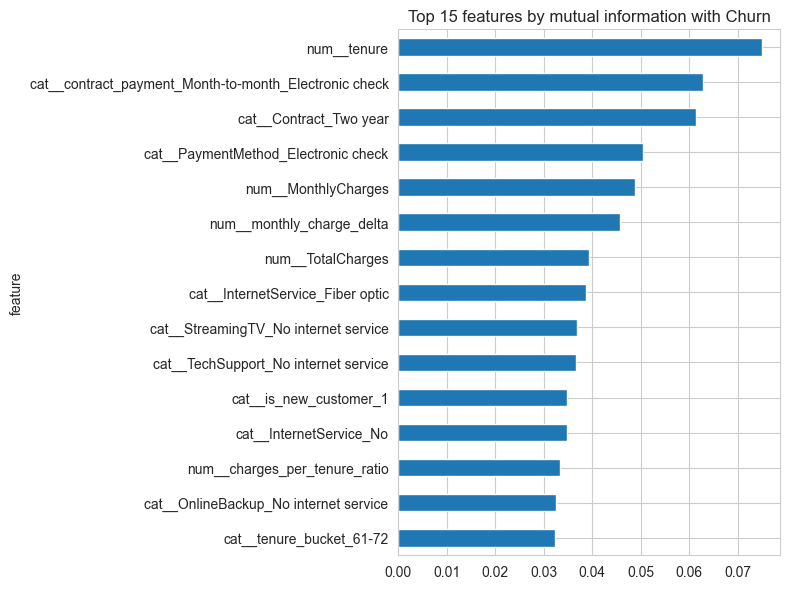

In [11]:
mi_scores = mutual_info_classif(X_train_enc, y_train, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': feat_names, 'mutual_info': mi_scores}).sort_values('mutual_info', ascending=False)
mi_df.head(15).plot(x='feature', y='mutual_info', kind='barh', figsize=(8, 6), legend=False,
                     title='Top 15 features by mutual information with Churn')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**RFECV (Recursive Feature Elimination with CV)** — fits the model repeatedly, dropping the weakest feature(s) each round, and cross-validates at every step to find the feature count that actually maximizes CV performance rather than just shrinking until told to stop.

RFECV selected 38 of 50 features


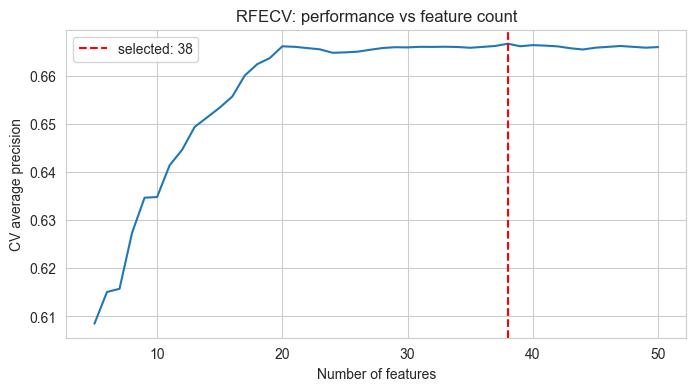

In [12]:
rfecv = RFECV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    step=1, min_features_to_select=5,
    cv=StratifiedKFold(3), scoring='average_precision', n_jobs=-1
)
rfecv.fit(X_train_enc, y_train)
print(f"RFECV selected {rfecv.n_features_} of {X_train_enc.shape[1]} features")

# cv_results_ also carries per-fold rankings/supports as 2D arrays; keep just
# the 1D scores for a simple scores-vs-feature-count plot.
n_features_tried = rfecv.cv_results_['n_features']
mean_scores = rfecv.cv_results_['mean_test_score']
cv_results = pd.DataFrame({'n_features': n_features_tried, 'mean_test_score': mean_scores})
plt.figure(figsize=(8, 4))
plt.plot(cv_results['n_features'], cv_results['mean_test_score'])
plt.axvline(rfecv.n_features_, color='red', linestyle='--', label=f'selected: {rfecv.n_features_}')
plt.xlabel('Number of features')
plt.ylabel('CV average precision')
plt.title('RFECV: performance vs feature count')
plt.legend()
plt.show()

**SelectFromModel** — a cheaper heuristic than RFECV: fit a model once (here, a Random Forest), then keep only features whose importance exceeds a threshold (`'median'` keeps the top half). No repeated refitting, so it scales to far more features than RFECV can practically handle.

In [13]:
sfm = SelectFromModel(RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), threshold='median')
sfm.fit(X_train_enc, y_train)
selected_by_sfm = feat_names[sfm.get_support()]
print(f"SelectFromModel (median threshold) kept {len(selected_by_sfm)} of {len(feat_names)} features")

SelectFromModel (median threshold) kept 25 of 50 features


### Does selecting features actually help?

More features isn't automatically worse — regularized models and tree ensembles are fairly robust to a moderate number of weak/redundant features. The only way to know if selection helps *this* problem is to measure it: compare CV performance with the full feature set against the RFECV-selected subset, same model, same folds.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

full_scores = cross_val_score(clf, X_train_enc, y_train, cv=cv, scoring='average_precision')
reduced_scores = cross_val_score(clf, rfecv.transform(X_train_enc), y_train, cv=cv, scoring='average_precision')

print(f"Full feature set     ({X_train_enc.shape[1]:2d} features): PR-AUC {full_scores.mean():.4f} (+/- {full_scores.std():.4f})")
print(f"RFECV-selected subset ({rfecv.n_features_:2d} features): PR-AUC {reduced_scores.mean():.4f} (+/- {reduced_scores.std():.4f})")

Full feature set     (50 features): PR-AUC 0.6647 (+/- 0.0165)
RFECV-selected subset (38 features): PR-AUC 0.6659 (+/- 0.0167)


## 6. Takeaways

- **Every engineered feature should survive a "why would this predict churn" sentence** — `num_addon_services` (switching cost), `is_new_customer` (buyer's-remorse churn regime), `contract_payment` (a documented high-risk combination), not features added because a for-loop over columns made them easy to generate.
- **Encoding choice should match the column's structure**, not default to one-hot everywhere: ordinal for genuinely ordered categories, target encoding for high-cardinality columns *if* it's computed out-of-fold, frequency encoding as a leak-free fallback.
- **Target encoding is the easiest place in a feature pipeline to leak the label** — the naive-vs-OOF gap above (0.975 vs ~0.68 train AUC on identical signal) is what that leak looks like when it's severe; it's subtler but still real even on low-cardinality columns.
- **VIF isn't just a linear-regression-class exercise** — it caught a genuine issue in this notebook's own feature engineering (an engineered "delta" that's an exact linear combination of two other features already in the set). Whether that issue matters depends entirely on what you're using the model *for*: irrelevant for prediction, disqualifying for coefficient interpretation.
- **Feature selection is worth measuring, not assuming.** Here, the RFECV-selected subset performs statistically indistinguishably from the full feature set — a legitimate result that argues for keeping the full set (simpler pipeline, one less moving part) rather than a failure of the selection method.